# Calculating the design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import os
from scipy.stats import skewnorm
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import spm_hrf
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix

plt.rcParams.update(plt.rcParamsDefault)
pd.set_option('display.max_rows', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','planning')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
input_dir = os.path.join('..', 'pre-processed', 'data_for_fMRI_modelling')
data = pd.read_csv(os.path.join(input_dir, 'combined_dataframe_binary_pilot_hard.csv'), sep= ';')
data = data.sort_values(by=['trial'], ascending=[True])
data = data.reset_index(drop=True)
print(data)

     index  subject_id  session  trial  stimuli_type  probability_condition  \
0      330         820        1      8             2                     80   
1      331         820        1      9             2                     80   
2        0         820        1     10             1                     20   
3        1         820        1     11             1                     20   
4      332         820        1     12             2                     80   
5      333         820        1     13             2                     80   
6        2         820        1     14             1                     20   
7      334         820        1     15             2                     80   
8        3         820        1     16             1                     20   
9        4         820        1     17             1                     20   
10       5         820        1     18             1                     20   
11       6         820        1     19             1

# Vary the ITI

In [4]:
# Now set ITI etc
trial_number =len(data)
median_iti = 3.5
simulate_iti = False
trial_list = list(range(trial_number))

if simulate_iti is True:
    # Add long breaks
    long_breaks = trial_list[0::round(trial_number/3)]
    print(long_breaks)
    
    # Add short breaks
    short_breaks = trial_list[0::30]
    print(short_breaks)
    
    generated_onset=[0]
    for i in range(1, trial_number):
        if i in long_breaks:
            print(i)
            generated_onset.append(generated_onset[i-1] + random.triangular(median_iti - 1, median_iti + 1))
        elif i in short_breaks and not i in long_breaks:
            print(i)
            generated_onset.append(generated_onset[i-1] + random.triangular(median_iti - 1, median_iti + 1) + 10)
        else:
            generated_onset.append(generated_onset[i-1] + random.triangular(median_iti - 1, median_iti + 1))
    
    print(generated_onset)

    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    data['emotional_cue_time_original'] = data['emotional_cue_time']
    data['emotional_cue_time'] = generated_onset
    
    data['response_time'] = data['emotional_cue_time'] + data['RT_s']
    
    print(data[['emotional_cue_time','emotional_cue_time_original','response_time','valence']])
else:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]

print(data[['trial','emotional_cue_time','valence']])

     trial  emotional_cue_time  valence
0        8            0.000000        1
1        9            4.322339        1
2       10            8.911544        0
3       11           12.388306        0
4       12           16.203898        1
5       13           20.766117        1
6       14           25.670165        0
7       15           29.224888        1
8       16           34.122939        0
9       17           38.109445        0
10      18           41.769115        0
11      19           46.241379        0
12      20           50.278861        1
13      21           54.526237        1
14      22           58.974513        0
15      23           62.559220        1
16      24           66.263868        0
17      25           69.785607        1
18      26           73.151424        1
19      27           76.724138        1
20      28           80.707646        0
21      29           85.275862        0
22      30           88.464768        1
23      31          102.673163        0


# Total duration

In [5]:
end_time = data['emotional_cue_time'].values[-1] + median_iti
end_time_min = end_time / 60
print(f'The full experiment takes {end_time_min:.0f} minutes')

The full experiment takes 48 minutes


# Quickly recode into something the design matrix can use

In [6]:
data['valence'] = data['valence'].replace({0:'angry', 1:'happy'})
data['congruency'] = data['congruency'].replace({0:'incongruent', 1:'congruent'})
data['volatility'] = data['volatility'].replace({0:'stable', 1:'volatile'})
data['valence-volatility'] = data['valence'] + '-' + data['volatility']

data['onset'] = data['emotional_cue_time']
data['duration'] = 1.8
print(data[['valence','congruency','volatility','valence-volatility','duration']])

    valence   congruency volatility valence-volatility  duration
0     happy  incongruent     stable       happy-stable       1.8
1     happy  incongruent     stable       happy-stable       1.8
2     angry  incongruent     stable       angry-stable       1.8
3     angry  incongruent     stable       angry-stable       1.8
4     happy  incongruent     stable       happy-stable       1.8
5     happy  incongruent     stable       happy-stable       1.8
6     angry  incongruent     stable       angry-stable       1.8
7     happy  incongruent     stable       happy-stable       1.8
8     angry  incongruent     stable       angry-stable       1.8
9     angry  incongruent     stable       angry-stable       1.8
10    angry  incongruent     stable       angry-stable       1.8
11    angry  incongruent     stable       angry-stable       1.8
12    happy  incongruent     stable       happy-stable       1.8
13    happy  incongruent     stable       happy-stable       1.8
14    angry  incongruent 

# Restructure the data into a timeseries

In [7]:
# Create the new dataframe by transforming the data
restructured_rows = []
for _, row in data.iterrows():
    restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['valence-volatility'], 'onset': row['onset'], 'duration': row['duration']})

# Convert to dataframe
data_design_matrix = pd.DataFrame(restructured_rows)

print(data_design_matrix)

          trial_type        onset  duration
0        incongruent     0.000000       1.8
1       happy-stable     0.000000       1.8
2        incongruent     4.322339       1.8
3       happy-stable     4.322339       1.8
4        incongruent     8.911544       1.8
5       angry-stable     8.911544       1.8
6        incongruent    12.388306       1.8
7       angry-stable    12.388306       1.8
8        incongruent    16.203898       1.8
9       happy-stable    16.203898       1.8
10       incongruent    20.766117       1.8
11      happy-stable    20.766117       1.8
12       incongruent    25.670165       1.8
13      angry-stable    25.670165       1.8
14       incongruent    29.224888       1.8
15      happy-stable    29.224888       1.8
16       incongruent    34.122939       1.8
17      angry-stable    34.122939       1.8
18       incongruent    38.109445       1.8
19      angry-stable    38.109445       1.8
20       incongruent    41.769115       1.8
21      angry-stable    41.76911

# Scanner info

In [8]:
# Repetition time
tr = 1.5

# Define scan volumes
time_length = math.ceil(max(data_design_matrix['onset']))
n_volumes = np.arange(0, time_length, tr)
total_volumes = len(n_volumes)
print(n_volumes)

[0.0000e+00 1.5000e+00 3.0000e+00 ... 2.8515e+03 2.8530e+03 2.8545e+03]


# Design matrix

In [9]:
plot_name = 'Design matrix'
events = pd.DataFrame(
    {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
)
print(events)

          trial_type        onset  duration
0        incongruent     0.000000       1.8
1       happy-stable     0.000000       1.8
2        incongruent     4.322339       1.8
3       happy-stable     4.322339       1.8
4        incongruent     8.911544       1.8
5       angry-stable     8.911544       1.8
6        incongruent    12.388306       1.8
7       angry-stable    12.388306       1.8
8        incongruent    16.203898       1.8
9       happy-stable    16.203898       1.8
10       incongruent    20.766117       1.8
11      happy-stable    20.766117       1.8
12       incongruent    25.670165       1.8
13      angry-stable    25.670165       1.8
14       incongruent    29.224888       1.8
15      happy-stable    29.224888       1.8
16       incongruent    34.122939       1.8
17      angry-stable    34.122939       1.8
18       incongruent    38.109445       1.8
19      angry-stable    38.109445       1.8
20       incongruent    41.769115       1.8
21      angry-stable    41.76911

In [10]:
design_matrix = make_first_level_design_matrix(
    n_volumes,
    data_design_matrix,
    drift_model = None
)
design_matrix = design_matrix[['angry-stable','happy-stable','angry-volatile','happy-volatile','congruent','incongruent','constant']]
print(design_matrix)

        angry-stable  happy-stable  angry-volatile  happy-volatile  \
0.0    -5.900697e-15 -6.154487e-15   -4.566033e-15   -6.646980e-15   
1.5    -2.371467e-15  4.070965e-03   -1.672764e-15   -2.519938e-15   
3.0     2.682946e-15  1.060220e-01    2.373831e-15    2.686705e-15   
4.5    -1.064594e-14  3.605636e-01   -8.701983e-15   -1.345369e-14   
6.0     6.581781e-15  4.928976e-01    5.266393e-15    7.208191e-15   
7.5    -2.901371e-16  5.082049e-01   -3.150716e-16   -5.769048e-16   
9.0     5.478077e-13  5.673585e-01    1.691388e-17   -8.213843e-17   
10.5    5.011041e-03  5.063076e-01   -2.383006e-16   -4.272186e-16   
12.0    1.143981e-01  2.979781e-01   -1.384551e-16   -2.535117e-16   
13.5    3.707781e-01  7.756870e-02   -2.341813e-16   -3.280365e-16   
15.0    5.458290e-01 -6.548326e-02   -6.029105e-16   -7.396159e-16   
16.5    6.674243e-01 -1.213385e-01   -4.013417e-16   -3.940122e-16   
18.0    6.542602e-01 -1.089383e-01   -4.832747e-16   -5.649546e-16   
19.5    4.405360e-01

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


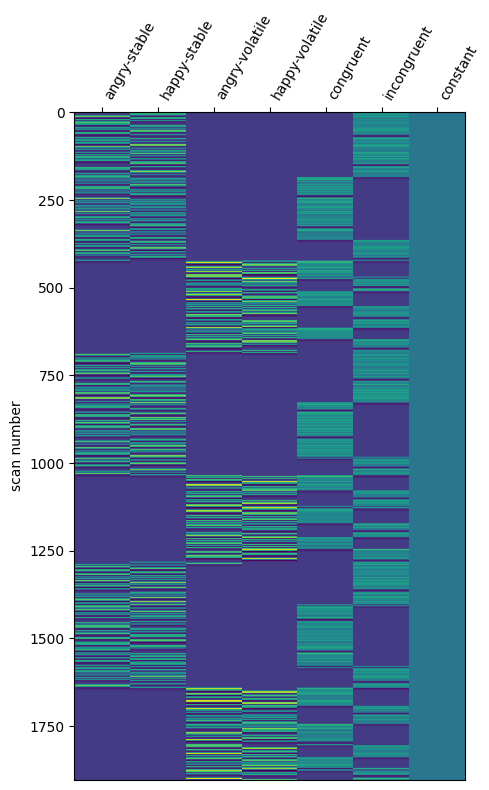

In [11]:
fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
plot_design_matrix(design_matrix, ax=ax)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

## Correlation matrix of the regressors

In [12]:
pd.set_option('display.width', 200)
correlation_matrix = design_matrix.corr()
correlation_matrix.round(3).to_csv(os.path.join(output_dir, 'regression_correlation_matrix.csv'), sep=';')
print(correlation_matrix)

                angry-stable  happy-stable  angry-volatile  happy-volatile  congruent  incongruent  constant
angry-stable        1.000000     -0.337529       -0.282201       -0.284800   0.018453     0.127808  0.299629
happy-stable       -0.337529      1.000000       -0.273265       -0.283408   0.030646     0.130229  0.134627
angry-volatile     -0.282201     -0.273265        1.000000       -0.200315   0.132295     0.000767 -0.334887
happy-volatile     -0.284800     -0.283408       -0.200315        1.000000   0.074880     0.014618 -0.320394
congruent           0.018453      0.030646        0.132295        0.074880   1.000000    -0.783496 -0.287428
incongruent         0.127808      0.130229        0.000767        0.014618  -0.783496     1.000000  0.169096
constant            0.299629      0.134627       -0.334887       -0.320394  -0.287428     0.169096  1.000000


# Raw HRF

In [13]:
plot_name = f'HRF for valence, first 200s, median ITI {median_iti}'
first_volume = 660
length = 860

fig = plt.figure(figsize=(15, 4))

n_volumes_selection = n_volumes[first_volume:length+1]
design_matrix_hrf_plot = design_matrix[first_volume:length]
#design_matrix_hrf_plot = design_matrix_hrf_plot.drop(columns=['congruent', 'incongruent', 'angry-stable', 'happy-stable', 'constant'])

plt.plot(design_matrix_hrf_plot['volatile'], label='angry-volatile', color='r')
plt.plot(design_matrix_hrf_plot['stable'], label='happy-volatile', color='g')
plt.xlabel("time (s)")
plt.legend()
plt.title(plot_name)

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8964/1615567232.py:8: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  design_matrix_hrf_plot = design_matrix[first_volume:length]


KeyError: 'volatile'

<Figure size 1500x400 with 0 Axes>